In [1]:
import astropy.units as u
import legwork as lw

In [2]:
s = lw.source.Source(m_1=1.4 * u.Msun, m_2=0.3 * u.Msun, ecc=0.0, f_orb=2.7e-5 * u.Hz, dist=1 * u.pc, interpolate_g=False)
s.get_snr(), s.get_merger_time()

(array([2.10625277]), <Quantity [13.98494813] Gyr>)

In [19]:
import cosmic
import os
import h5py as h5

In [43]:
import pandas as pd

In [ ]:
with h5.File(os.path.join("/mnt/ceph/users/twagg/lisa-dcos/fiducial/", file), "r") as f:
    print(f["stroopwafel"]["weights"])

<HDF5 group "/bpp" (6 members)>
<HDF5 dataset "weights": shape (500000,), type "<f8">


In [39]:
# loop through every file in "folder_path"
Zs = []
hits = []

for file in os.listdir("/mnt/ceph/users/twagg/lisa-dcos/fiducial/"):
    # check if the file ends with ".h5"
    if file.endswith(".h5"):
        # create a COSMICStroopOutput object from the file
        with h5.File(os.path.join("/mnt/ceph/users/twagg/lisa-dcos/fiducial/", file), "r") as f:
            print(f["stroopwafel"]["weights"])
            Zs.append(float(file.split("_")[-1].split(".h5")[0]))
            hits.append(f["stroopwafel"].attrs["num_hits"])

<HDF5 dataset "weights": shape (500000,), type "<f8">
<HDF5 dataset "weights": shape (500000,), type "<f8">
<HDF5 dataset "weights": shape (500000,), type "<f8">
<HDF5 dataset "weights": shape (500000,), type "<f8">
<HDF5 dataset "weights": shape (500000,), type "<f8">
<HDF5 dataset "weights": shape (500000,), type "<f8">
<HDF5 dataset "weights": shape (500000,), type "<f8">
<HDF5 dataset "weights": shape (500000,), type "<f8">
<HDF5 dataset "weights": shape (500000,), type "<f8">
<HDF5 dataset "weights": shape (500000,), type "<f8">
<HDF5 dataset "weights": shape (500000,), type "<f8">
<HDF5 dataset "weights": shape (500000,), type "<f8">
<HDF5 dataset "weights": shape (500000,), type "<f8">
<HDF5 dataset "weights": shape (500000,), type "<f8">
<HDF5 dataset "weights": shape (500000,), type "<f8">
<HDF5 dataset "weights": shape (500000,), type "<f8">
<HDF5 dataset "weights": shape (500000,), type "<f8">
<HDF5 dataset "weights": shape (500000,), type "<f8">
<HDF5 dataset "weights": sha

In [ ]:
cosmic.output.COSMICStroopOutput.from_file

cosmic.output.COSMICStroopOutput

In [10]:
import cogsworth
import matplotlib.pyplot as plt
import gala.potential as gp
import numpy as np

In [6]:
s = cogsworth.sfh.SandersBinney2015(potential=gp.MilkyWayPotential(version='v2'))
s.sample(200_000)

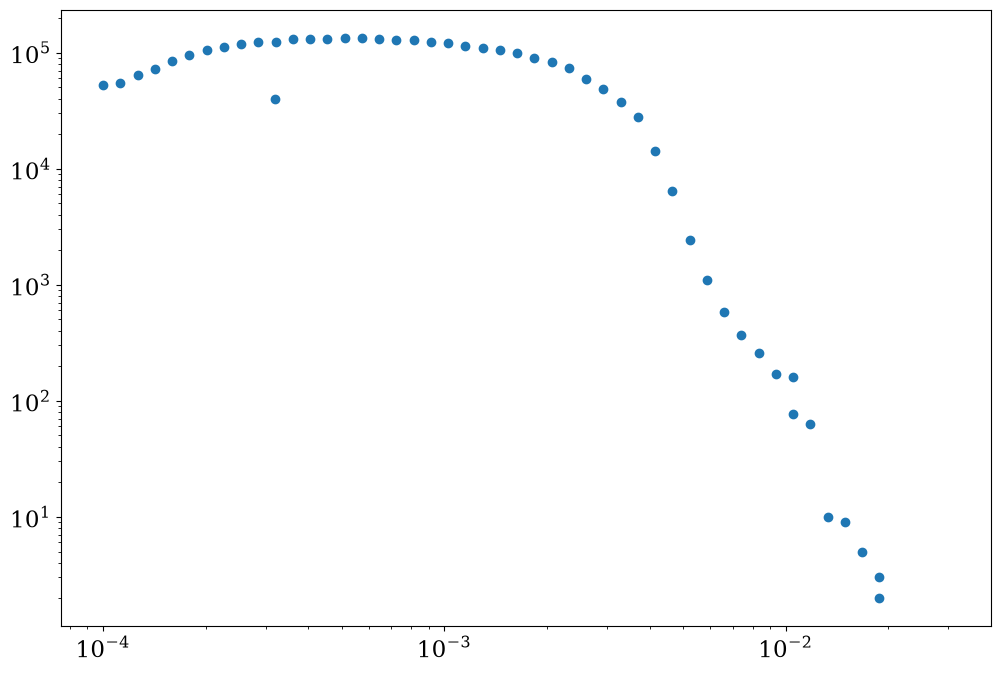

In [35]:
plt.loglog(Zs, hits, marker='o', linestyle='none')
# plt.yscale("log")

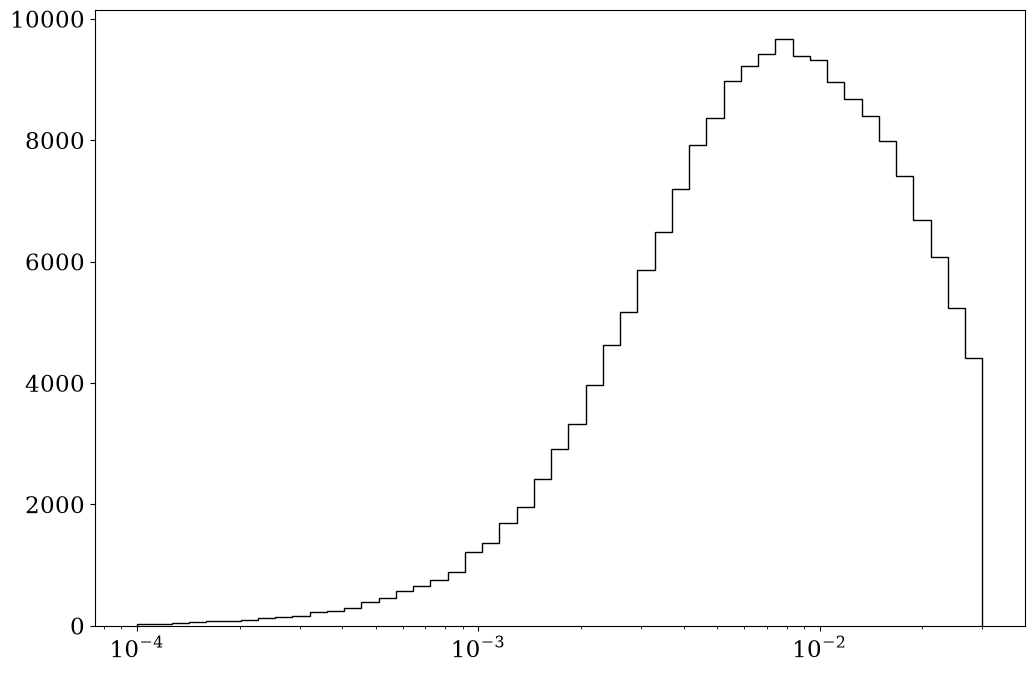

In [36]:
plt.hist(s.Z, bins=np.logspace(-4, np.log10(0.03), 50), histtype='step', color='k')
plt.xscale("log")